# Phase 2: Chest X-Ray Dataset Loading for Modeling

This notebook turns the Phase 1 preprocessing outputs into PyTorch-ready datasets. The focus is to connect each X-ray image path with its 14 disease labels, apply consistent image transforms, verify tensor shapes, preview representative images, and create batch loaders for model training and evaluation.

## 1. Import libraries, mount the image dataset, and define the dataset class

The notebook begins with the libraries needed for Kaggle access, image loading, tabular metadata, visualization, and PyTorch dataset creation. Mounting the NIH Chest X-ray image dataset is necessary because the Phase 1 CSV files store paths that must point to real image files during training.

`ChestImageDataset` wraps each Phase 1 CSV file in a PyTorch `Dataset`. It reads image paths from `full_path`, opens each X-ray as a three-channel image, extracts the 14 disease labels, applies optional transforms, and returns one `(image, labels)` pair for any row index.


In [1]:
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.transforms import Compose


# Instantly mounts the entire image folder system-wide in the background
# It returns the root directory containing all the 'images_001', 'images_002', etc. subfolders.
dataset_root_dir = Path(kagglehub.dataset_download("nih-chest-xrays/data"))

print(f"The images folder is mounted at: {dataset_root_dir}")



class ChestImageDataset(Dataset):
    def __init__(self, csv_url, transforms=None):
        self.data = pd.read_csv(csv_url)
        self.target_cols  = self.data.columns[10:-1].tolist()
        self.transforms = transforms
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        
        # Instant O(1) path lookup
        img_path = row['full_path']
        
        # Open and standardise image channels
        image = Image.open(img_path).convert("RGB")
        
        # Extract your one-hot columns
        labels = row[self.target_cols].values.astype('float32')
        labels = torch.tensor(labels)
        
        if self.transforms:
            image = self.transforms(image)
            
        return image, labels

The images folder is mounted at: /kaggle/input/datasets/organizations/nih-chest-xrays/data


The printed path confirms that the Kaggle image dataset is available in the notebook environment. The class definition does not print output, but once it is defined, later cells can use the Phase 1 `full_path` column to open each X-ray file directly and return model-ready tensors.


## 2. Define image preprocessing transforms

The transform pipeline resizes every X-ray to `224 x 224`, converts it to a tensor, and normalizes it with ImageNet mean and standard deviation values. This prepares the images for common pretrained CNN backbones, which usually expect three-channel normalized inputs at this size.


In [2]:
data_transform = Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

This cell has no printed output. Successful execution creates `data_transform`, which standardizes all splits before they enter the model.


## 3. Build and check the training dataset

The training CSV from Phase 1 is loaded into the custom dataset class with the transform pipeline attached. A single training example is then indexed to confirm that image loading, resizing, tensor conversion, and label extraction all work before creating batches.


In [16]:
train_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/train_data.csv",  
    transforms=data_transform
)
image,labels = train_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The output shows an image tensor shaped `[3, 224, 224]` and a label tensor shaped `[14]`. That confirms each image is converted to three channels, resized correctly, and paired with one target value per disease label.


A representative training image is displayed with its positive label names as the title. This visual check helps confirm that `full_path` points to the correct X-ray file and that the label columns are being interpreted correctly.


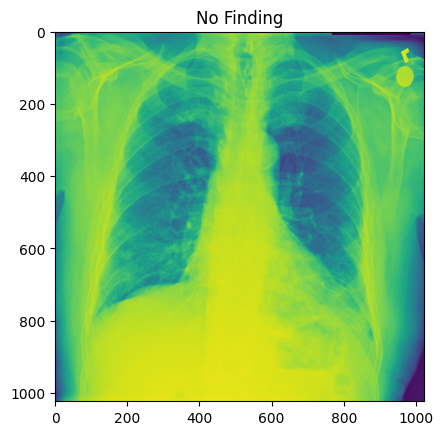

In [34]:
row = train_dataset.data.iloc[3]
img = Image.open(row["full_path"])
positive = [c for c in train_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

The displayed image provides a human-readable check of one training example. If the title contains disease names, those are the positive labels for that row; otherwise, the example is labeled `No Finding`.


## 4. Build and check the validation dataset

The validation CSV is loaded with the same dataset class and transforms. Matching preprocessing across training and validation makes validation metrics easier to interpret, while the split itself remains patient-safe from Phase 1.


In [18]:
val_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/val_data.csv",  
    transforms=data_transform
)

image,labels = val_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The output again shows `[3, 224, 224]` for the image and `[14]` for the labels. This confirms that validation examples follow the same tensor contract as training examples.


A representative validation image is displayed with its positive labels. This gives a quick visual sanity check that the validation split uses the same image-path and label-reading logic as the training split.


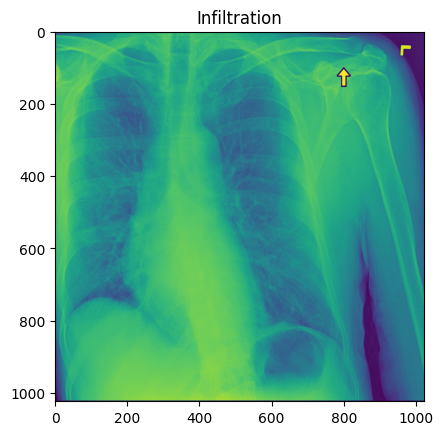

In [19]:
row = val_dataset.data.iloc[1001]
img = Image.open(row["full_path"])
positive = [c for c in val_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

The displayed validation example provides a quick check that the validation image files and labels are aligned before the model uses this split for tuning.


## 5. Build and check the test dataset

The official test CSV is loaded into the same dataset structure. Keeping test preprocessing identical to training and validation ensures the final evaluation measures model behavior rather than differences in input preparation.


In [20]:
test_dataset = ChestImageDataset(
    csv_url = "/kaggle/input/datasets/aarshdesai05/chest-xray-data/test_data.csv",  
    transforms=data_transform
)
image,labels = test_dataset[0]
print(image.shape)
print(labels.shape)

torch.Size([3, 224, 224])
torch.Size([14])


The output confirms the same tensor structure: image shape `[3, 224, 224]` and label shape `[14]`. This consistency is important before writing a shared evaluation loop.


A representative test image is displayed with its positive labels. This final split-level visual check helps verify that the held-out evaluation data can be opened and interpreted consistently.


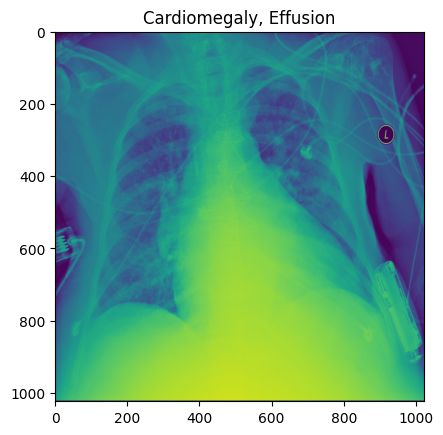

In [21]:
row = test_dataset.data.iloc[1001]
img = Image.open(row["full_path"])
positive = [c for c in test_dataset.target_cols if row[c] == 1]
title = ", ".join(positive) if positive else "No Finding"
plt.imshow(img)
plt.title(title)
plt.show()

The displayed test example checks that the held-out split can be inspected in the same way as the training and validation splits.


## 6. Create the training DataLoader

The training dataset is wrapped in a `DataLoader` so model training can consume mini-batches instead of individual images. Shuffling is enabled for training to avoid learning from CSV order, and `num_workers=2` lets image loading happen in parallel.


In [7]:
train_data = DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2)

This cell does not print output. Successful execution creates `train_data`, the iterable batch loader that will feed images and labels into the model.


A batch-level check confirms that the training `DataLoader` combines individual samples correctly. This is useful because dataset-level checks only prove that one row works; the training loop needs batches with the expected dimensions.


In [8]:
images, labels = next(iter(train_data))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 14])


The batch output should show images shaped `[32, 3, 224, 224]` and labels shaped `[32, 14]`. That means the loader is producing batches of 32 transformed X-rays with matching multi-label targets.


## 7. Create the validation DataLoader

The validation dataset is also wrapped in a `DataLoader` using the same batch size. Validation data is not shuffled here so evaluation remains stable and easier to reproduce.


In [22]:
val_data = DataLoader(val_dataset,batch_size=32,num_workers=2)

This cell does not print output. Successful execution creates `val_data`, which can be used during training to measure validation performance after each epoch.


A validation batch is checked to confirm that the loader returns the same tensor contract as the training loader: one batch of transformed X-rays and one batch of multi-label targets.


In [29]:
images,labels = next(iter(val_data))
print(images.shape,labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 14])


The validation batch output should match the training batch structure: images shaped `[32, 3, 224, 224]` and labels shaped `[32, 14]`.


## 8. Create the test DataLoader

The test dataset is wrapped in a final `DataLoader` for held-out evaluation. Using the same batch size and loading settings keeps evaluation code simple across validation and test splits.


In [23]:
test_data = DataLoader(test_dataset,batch_size=32,num_workers=2)

This cell does not print output. Successful execution creates `test_data`, preserving the official held-out split for final model evaluation.


A test batch is checked as the final loading sanity check. Matching batch shapes across all splits means the same model forward pass and metric code can be reused.


In [30]:
images,labels = next(iter(test_data))
print(images.shape,labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 14])


The test batch output should also match the shared batch structure. Consistent DataLoader outputs across training, validation, and test splits make the next modeling phase simpler and less error-prone.


## Phase 2 Dataset Loading Summary

- Imported Kaggle, pandas, PIL, PyTorch, torchvision, and matplotlib utilities so the notebook can access data, read metadata, open images, transform tensors, visualize examples, and build batches.
- Mounted the NIH Chest X-ray image dataset because the Phase 1 CSV files depend on valid `full_path` entries.
- Defined `ChestImageDataset` to convert each CSV row into a PyTorch-compatible `(image, labels)` pair.
- Used the Phase 1 `full_path` column so image lookup is direct and does not require searching through folders during training.
- Converted X-rays to RGB because many pretrained CNN models expect 3-channel input.
- Extracted the 14 disease label columns as floating-point tensors because this is a multi-label classification task.
- Applied resizing, tensor conversion, and normalization so every split follows the same image preprocessing contract.
- Created training, validation, and test datasets from the Phase 1 CSV exports to preserve the patient-safe split structure.
- Checked one sample from each split to verify image tensors shaped `[3, 224, 224]` and label tensors shaped `[14]`.
- Displayed representative examples from each split with positive labels in the plot title for visual sanity checking.
- Built training, validation, and test `DataLoader` objects with batch size `32` so model training and evaluation can consume mini-batches.
- Checked one batch from each loader to confirm images are shaped `[32, 3, 224, 224]` and labels are shaped `[32, 14]`.
